<a href="https://colab.research.google.com/github/Dilini8888/student-performance-prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 500

data = {
    "student_id": range(1, n_students + 1),
    "age": np.random.randint(18, 25, n_students),
    "study_hours": np.round(np.random.uniform(1, 10, n_students), 1),
    "attendance": np.round(np.random.uniform(50, 100, n_students), 1),
    "previous_score": np.round(np.random.uniform(40, 95, n_students), 1),
    "assignment_score": np.round(np.random.uniform(40, 100, n_students), 1),
    "sleep_hours": np.round(np.random.uniform(4, 9, n_students), 1),
    "internet_hours": np.round(np.random.uniform(1, 8, n_students), 1)
}

df = pd.DataFrame(data)

df.head()

df["final_score"] = (
    0.30 * df["previous_score"] +
    0.25 * df["assignment_score"] +
    0.20 * df["study_hours"] * 10 +
    0.15 * df["attendance"] +
    0.05 * df["sleep_hours"] * 10 +
    0.05 * (10 - df["internet_hours"]) * 10
)

df["final_score"] = df["final_score"].clip(0, 100).round(1)

df.head()

,student_id,age,study_hours,attendance,previous_score,assignment_score,sleep_hours,internet_hours,final_score
0,1,24,3.7,55.0,51.0,66.6,7.0,2.5,54.8
1,2,21,5.8,62.8,78.1,42.9,6.7,4.2,61.4
2,3,22,3.9,86.3,85.2,42.3,8.3,7.4,62.3
3,4,24,8.5,79.6,42.3,84.8,4.2,2.2,68.8
4,5,20,3.4,55.1,76.9,79.5,8.2,2.5,65.9


In [2]:
df.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [3]:
from google.colab import files

files.download("student_performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        500 non-null    int64  
 1   age               500 non-null    int64  
 2   study_hours       500 non-null    float64
 3   attendance        500 non-null    float64
 4   previous_score    500 non-null    float64
 5   assignment_score  500 non-null    float64
 6   sleep_hours       500 non-null    float64
 7   internet_hours    500 non-null    float64
 8   final_score       500 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 35.3 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
student_id,0
age,0
study_hours,0
attendance,0
previous_score,0
assignment_score,0
sleep_hours,0
internet_hours,0
final_score,0


In [7]:
df.describe()

,student_id,age,study_hours,attendance,previous_score,assignment_score,sleep_hours,internet_hours,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,20.954000,5.565400,75.510400,67.198000,69.368200,6.592000,4.555400,65.9774
std,144.481833,2.027833,2.529827,14.822363,14.955008,17.741035,1.440864,1.994198,8.4490
min,1.000000,18.000000,1.000000,50.000000,40.000000,40.000000,4.000000,1.000000,41.0000
25%,125.750000,19.000000,3.400000,62.600000,54.000000,53.575000,5.375000,2.900000,60.1000
50%,250.500000,21.000000,5.800000,76.100000,67.800000,69.000000,6.700000,4.600000,65.8500
75%,375.250000,23.000000,7.600000,88.600000,78.275000,84.825000,7.800000,6.325000,71.5250
max,500.000000,24.000000,10.000000,100.000000,94.800000,99.800000,9.000000,8.000000,92.0000


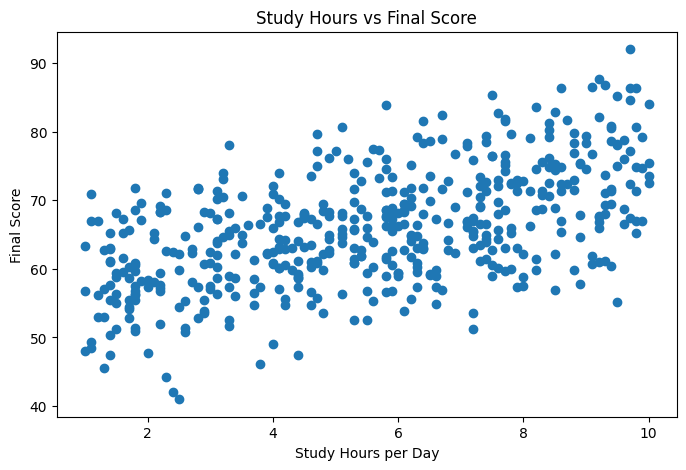

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["study_hours"], df["final_score"])

plt.xlabel("Study Hours per Day")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.show()

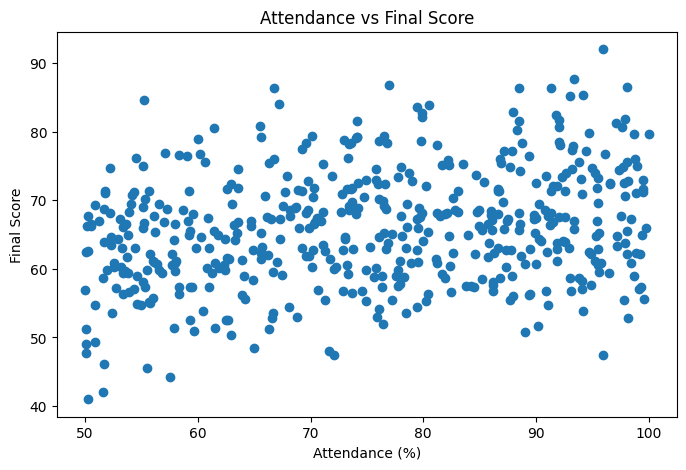

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(df["attendance"], df["final_score"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.show()

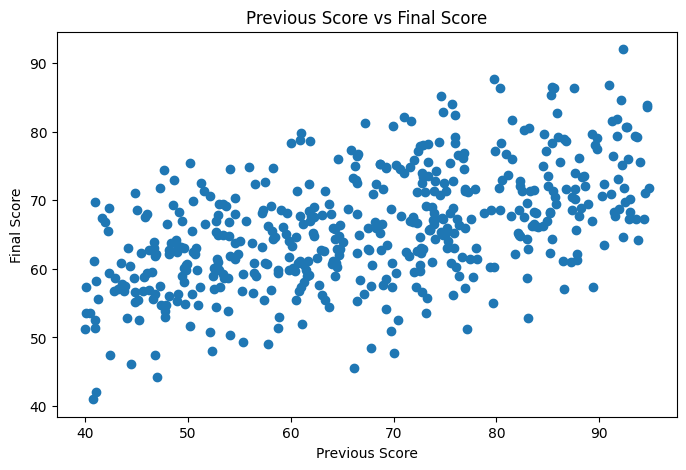

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(df["previous_score"], df["final_score"])

plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.title("Previous Score vs Final Score")

plt.show()

In [11]:
correlation = df.corr(numeric_only=True)

correlation["final_score"].sort_values(ascending=False)

,final_score
final_score,1.000000
study_hours,0.559307
previous_score,0.536412
assignment_score,0.530479
attendance,0.258042
sleep_hours,0.157165
student_id,0.008803
age,0.004454
internet_hours,-0.172811


In [12]:
X = df.drop(columns=["student_id", "final_score"])
y = df["final_score"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['age', 'study_hours', 'attendance', 'previous_score',
       'assignment_score', 'sleep_hours', 'internet_hours'],
      dtype='object')

Target:
final_score


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 7)
Testing data: (100, 7)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[57.39552767 80.25766063 62.82775915 64.21036076 61.96329618 65.64717243
 70.707707   63.05947282 61.74644232 68.28163445]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

Model Evaluation
-----------------
MAE: 0.03
RMSE: 0.03
R² Score: 1.0


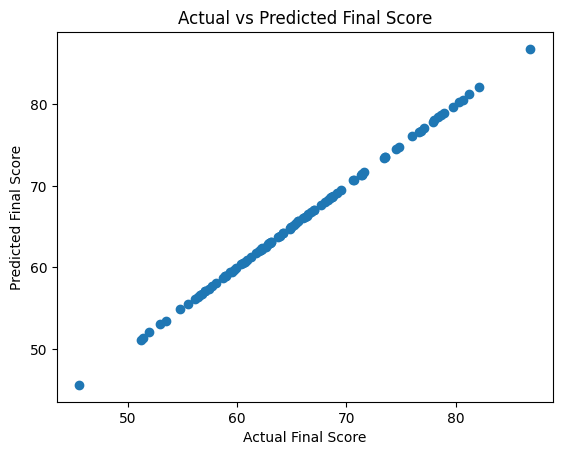

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")

plt.show()

In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,study_hours,1.999986
5,sleep_hours,0.500689
3,previous_score,0.300028
4,assignment_score,0.249970
2,attendance,0.150108
0,age,-0.000534
6,internet_hours,-0.500414


In [19]:
residuals = y_test - y_pred

print("Mean Residual:", round(residuals.mean(), 2))
print("Maximum Error:", round(abs(residuals).max(), 2))

Mean Residual: 0.0
Maximum Error: 0.05


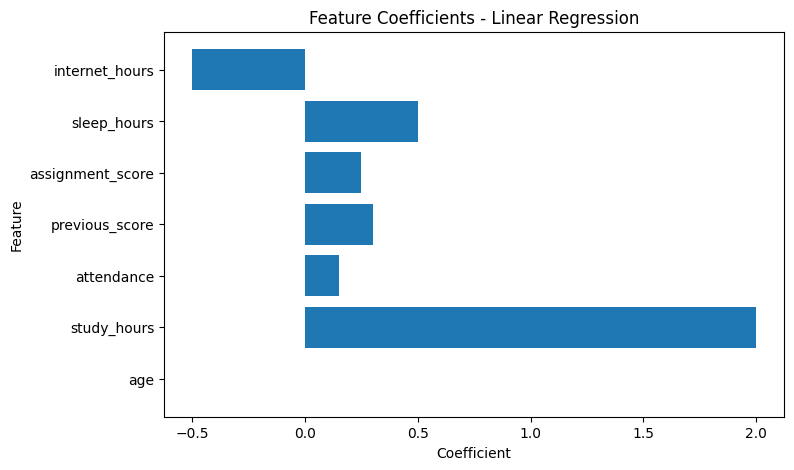

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(coefficients["Feature"], coefficients["Coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients - Linear Regression")

plt.show()

In [21]:
new_student = pd.DataFrame({
    "age": [21],
    "study_hours": [7],
    "attendance": [85],
    "previous_score": [75],
    "assignment_score": [80],
    "sleep_hours": [8],
    "internet_hours": [3]
})

predicted_score = model.predict(new_student)

print("Predicted Final Score:", round(predicted_score[0], 2))

Predicted Final Score: 76.75


## New Student Prediction

The trained Linear Regression model was used to predict the final score of a new student.

Example prediction:
- Age: 21
- Study Hours: 7 hours/day
- Attendance: 85%
- Previous Score: 75
- Assignment Score: 80
- Sleep Hours: 8 hours
- Internet Hours: 3 hours/day

**Predicted Final Score: 76.75**

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred[:10])

Random Forest Predictions:
[59.188 76.909 62.398 61.595 63.26  65.744 71.66  64.511 61.015 67.729]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Model Evaluation")
print("------------------------------")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R² Score:", round(rf_r2, 2))

Random Forest Model Evaluation
------------------------------
MAE: 1.73
RMSE: 2.24
R² Score: 0.92


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
4  assignment_score    0.326233
1       study_hours    0.318817
3    previous_score    0.263505
2        attendance    0.049703
6    internet_hours    0.020759
5       sleep_hours    0.013559
0               age    0.007424


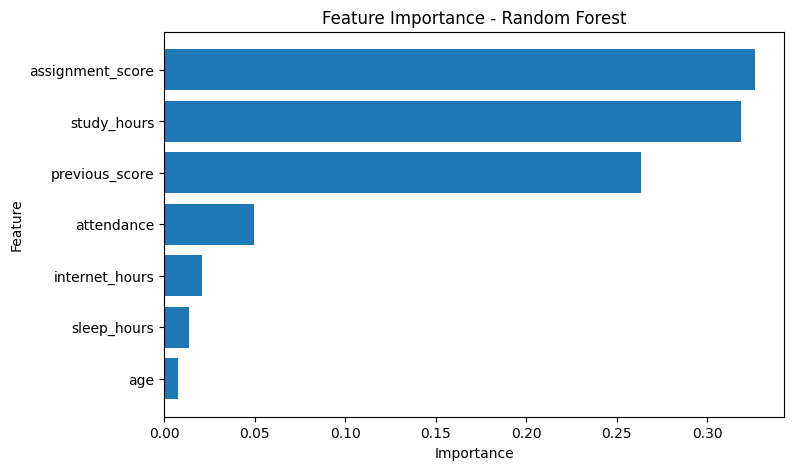

In [26]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()
plt.show()

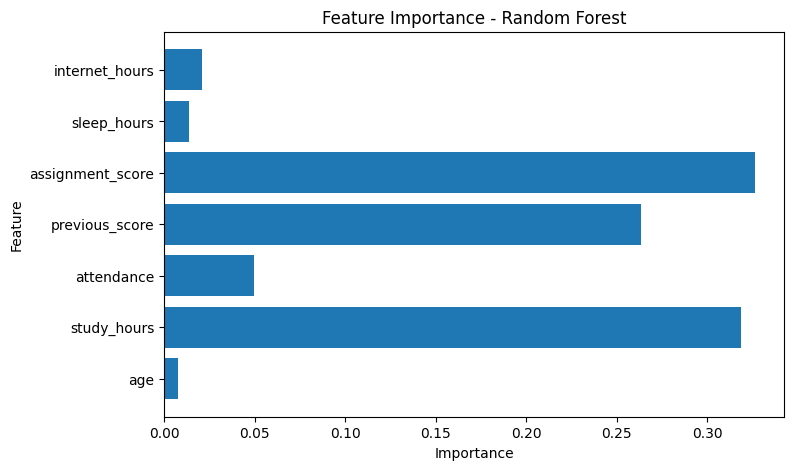

In [27]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(X.columns, importance)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()

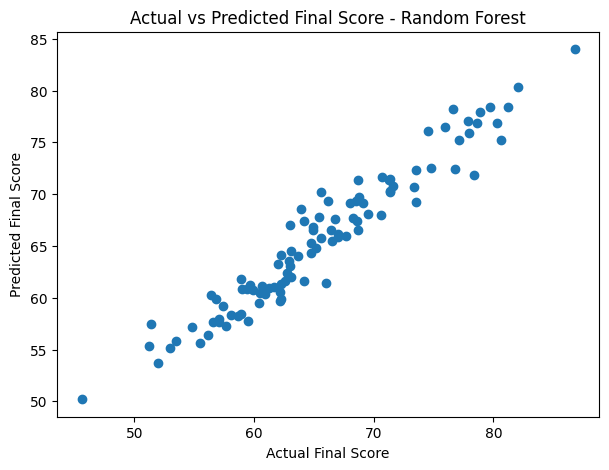

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score - Random Forest")

plt.show()

In [29]:
new_student = pd.DataFrame({
    "age": [21],
    "study_hours": [7],
    "attendance": [85],
    "previous_score": [75],
    "assignment_score": [80],
    "sleep_hours": [8],
    "internet_hours": [3]
})

rf_new_prediction = rf_model.predict(new_student)

print("Random Forest Predicted Final Score:",
      round(rf_new_prediction[0], 2))

Random Forest Predicted Final Score: 75.12


In [30]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, 1.73],
    "RMSE": [rmse, 2.24],
    "R2 Score": [r2, 0.92]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.026811,0.03029,0.999986
1,Random Forest,1.730000,2.24000,0.920000


## Conclusion

This project developed machine learning models to predict students' final scores
using academic and lifestyle-related features.

Two regression models, Linear Regression and Random Forest Regression, were trained
and evaluated using MAE, RMSE, and R² Score.

The analysis also showed that assignment score, study hours, and previous score
were among the most important features for predicting final performance.

The trained models can be used to estimate the final score of a new student based
on their input features.